/tmp/ipykernel_1724113/4138927841.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


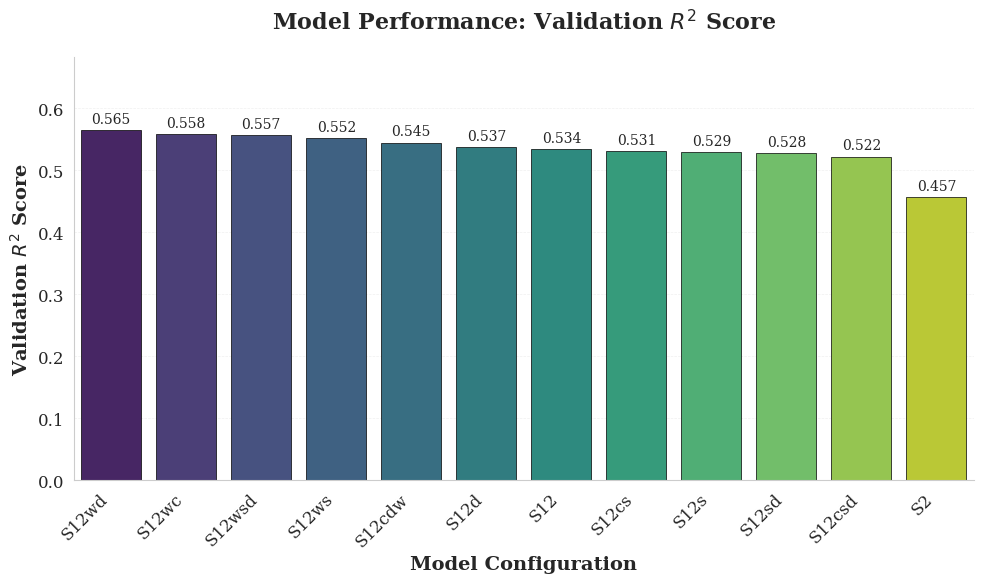

/tmp/ipykernel_1724113/4138927841.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


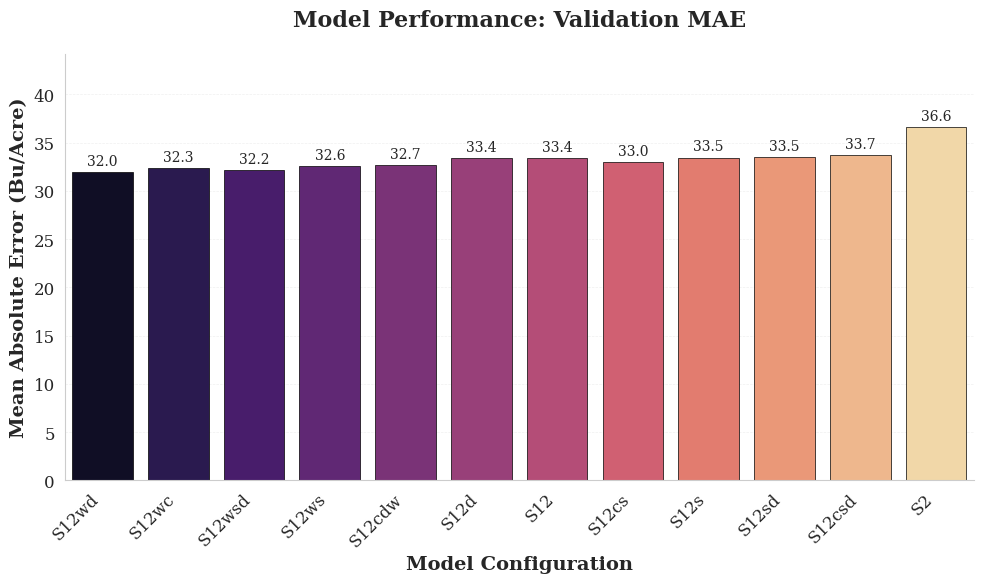

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("Modality_Config.csv")

# Filter out rows with missing val/R2_Score
df = df[df["val/R2_Score (Max)"].notnull()]

# Ignore repeats
df = df.drop_duplicates(subset="Name", keep="first")

# Sort by val/R2_Score descending for better visualization
df = df.sort_values("val/R2_Score (Max)", ascending=False)
df['val/MAE (Min)'] = df['val/MAE (Min)'] * 370

# Create short labels by splitting on '-' and taking first component
df['Short_Name'] = df['Name'].str.split('-').str[0]

# Set publication-ready style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 16

# Plot Validation R²
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/R2_Score (Max)",
    palette="viridis",
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)
ax.set_xlabel("Model Configuration", fontsize=14, fontweight='bold')
ax.set_ylabel("Validation $R^2$ Score", fontsize=14, fontweight='bold')
ax.set_title("Model Performance: Validation $R^2$ Score", fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("val_r2_by_experiment.pdf", bbox_inches="tight", dpi=300)
plt.savefig("val_r2_by_experiment.png", bbox_inches="tight", dpi=300)
plt.show()

# Plot Validation MAE
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/MAE (Min)",
    palette="magma",
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
ax.set_xlabel("Model Configuration", fontsize=14, fontweight='bold')
ax.set_ylabel("Mean Absolute Error (Bu/Acre)", fontsize=14, fontweight='bold')
ax.set_title("Model Performance: Validation MAE", fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("val_mae_by_experiment.pdf", bbox_inches="tight", dpi=300)
plt.savefig("val_mae_by_experiment.png", bbox_inches="tight", dpi=300)
plt.show()

In [2]:
df.sort_values('Short_Name')

,Name,val/MAE (Min),val/R2_Score (Max),val/loss (Min),Short_Name
6,S12-0.5(lr-factor),33.371433,0.534010,0.014352,S12
4,S12cdw-0.5(lr-factor),32.693700,0.544669,0.013927,S12cdw
7,S12cs-0.5(lr-factor),33.004189,0.531208,0.014365,S12cs
11,S12csd-0.5(lr-factor),33.695300,0.522183,0.014653,S12csd
5,S12d-0.5(lr-factor),33.372009,0.537144,0.014231,S12d
8,S12s-0.5(lr-factor),33.450727,0.528881,0.014409,S12s
9,S12sd-0.5(lr-factor),33.480853,0.528466,0.014373,S12sd
1,S12wc-0.5(lr-factor),32.346454,0.557994,0.013536,S12wc
0,S12wd-0.5(lr-factor),31.979948,0.565481,0.013309,S12wd
3,S12ws-0.5(lr-factor),32.589714,0.552151,0.013672,S12ws


/tmp/ipykernel_1724113/3999452083.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


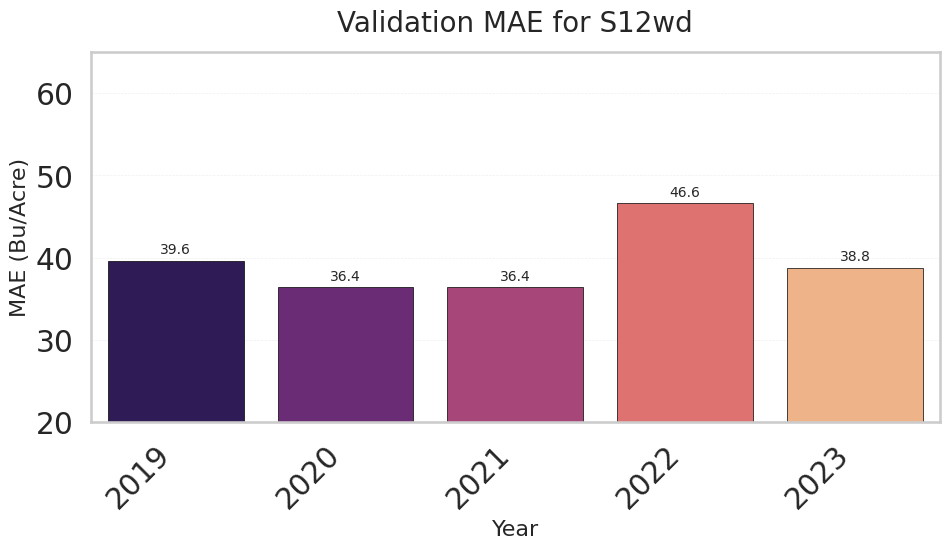

In [ ]:
# Replace the Terramind_year MAE line plot with a bar plot
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("Terramind_year.csv")

# Convert validation MAE column to numeric (handles any missing/empty values)
df["val/MAE (Min)"] = pd.to_numeric(df["val/MAE (Min)"], errors='coerce')
df["val/MAE (Min)"] = df["val/MAE (Min)"] * 370  # Scale MAE if needed
# # Reverse the order
# df = df.iloc[::-1].reset_index(drop=True)

# Create short labels by splitting on '_' and taking last component (year)
df['Short_Name'] = df['Name'].str.split('_').str[-1].astype(int)
df.sort_values('Short_Name').reset_index(drop=True, inplace=True)
# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/MAE (Min)",
    palette="magma",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

ax.set_title(f"Validation MAE for {df['Name'].iloc[0].split('_')[0]}", fontsize=20, pad=15)
ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("MAE (Bu/Acre)", fontsize=16)
ax.set_ylim(20, 65)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("val_mae_barplot_year.pdf", bbox_inches='tight', dpi=300)
plt.savefig("val_mae_barplot_year.png", bbox_inches='tight', dpi=300)
plt.show()
# ...existing code...

/tmp/ipykernel_1724113/3557848453.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


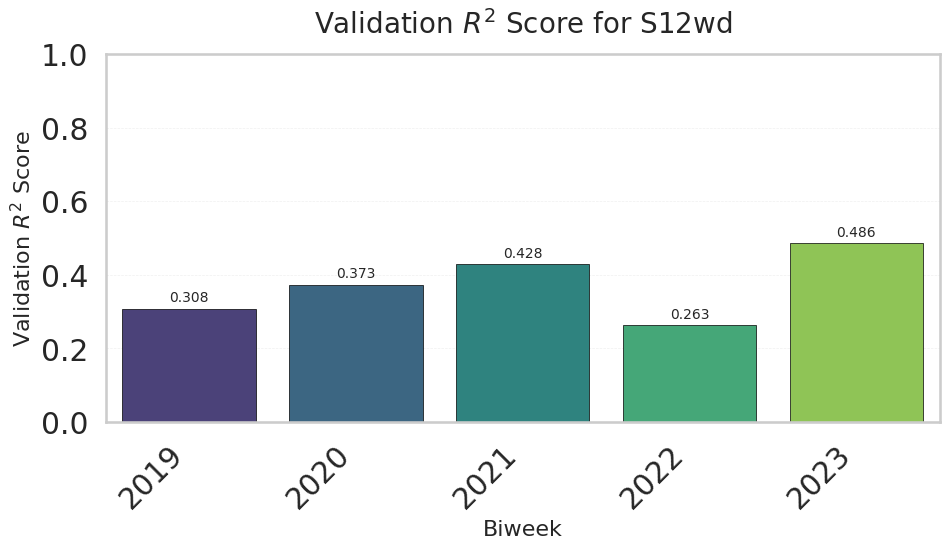

In [4]:
# Replace the Terramind_test R2 line plot with a bar plot
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("Terramind_year.csv")

# Convert validation R2 column to numeric (handles any missing/empty values)
df["val/R2_Score (Max)"] = pd.to_numeric(df["val/R2_Score (Max)"], errors='coerce')
# Reverse the order
df = df.iloc[::-1].reset_index(drop=True)

# Create short labels by splitting on '_' and taking second component
df['Short_Name'] = df['Name'].str.split('_').str[-1].astype(int)
df.sort_values('Short_Name').reset_index(drop=True, inplace=True)
# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/R2_Score (Max)",
    palette="viridis",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

ax.set_title(f"Validation $R^2$ Score for {df['Name'].iloc[0].split('_')[0]}", fontsize=20, pad=15)
ax.set_xlabel("Biweek", fontsize=16)
ax.set_ylabel("Validation $R^2$ Score", fontsize=16)
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("val_r2_barplot_year.pdf", bbox_inches='tight', dpi=300)
plt.savefig("val_r2_barplot_year.png", bbox_inches='tight', dpi=300)
plt.show()
# ...existing code...